In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li{font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
</style>
"""))

# ※ Quiz : 경주여행과 전주여행에 대해 최빈단어시각화와 유사도분석
- (1) naver open API를 활용하여 블로그에 "경주여행", "전주여행"을 각각 500건씩 검색하여 백업
    (data/quiz/naver.csv)
    * 파일 내용 : query, no, title, link, description, total_text(title + ' ' + description)
- (2) naver.csv에서 total_text를 품사태깅(naver_pos.csv)
    * 파일 내용 : query, no, token, pos
- (3) 명사만 추출(naver_pos_nouns.csv)
    * query, toke, pos
- (4) 빈도분석 백업(naver_pos_nouns_count.csv)
    * token, 경주빈도, 전주빈도, 빈도합
- (5) 빈도 시각화(워드클라우드, Text.plot)
    * 이미지 저장
- (6) 단어간 거리 분석(Word2Vec), 단어간 연관분석

## 1. 네이버 open API 활용하여 검색 추출
- query, no, title, link, description, total_text(title + ' ' + description)

In [2]:
# .env 가져오기
from dotenv import load_dotenv
import os
load_dotenv()

True

In [3]:
# 네이버 개발자 센터에 있는 소스를 가져오기
# 네이버 검색 API 예제 - 블로그 검색
import os
import sys
import urllib.request
client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')
encText = urllib.parse.quote("경주 여행")
url = "https://openapi.naver.com/v1/search/blog.json?query=" + encText # JSON 결과
# url = "https://openapi.naver.com/v1/search/blog.xml?query=" + encText # XML 결과
request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id",client_id)
request.add_header("X-Naver-Client-Secret",client_secret)
response = urllib.request.urlopen(request)
rescode = response.getcode()
if(rescode==200):
    response_body = response.read()
    print(response_body.decode('utf-8')[:200])
else:
    print("Error Code:" + rescode)

{
	"lastBuildDate":"Fri, 04 Sep 2026 09:38:13 +0900",
	"total":2737319,
	"start":1,
	"display":10,
	"items":[
		{
			"title":"3월의 <b>경주여행<\/b>.",
			"link":"https:\/\/lje77777.tistory.com\/7132",
			"


In [4]:
# 문자->dict
import json
from html import unescape # description에 있는 &lt;(특수문자)를 <로 변경
import requests
import pandas as pd
import re  # 특수문자 제거 @@ _._

In [5]:
query = "경주 여행"
start = 1
#url = f"https://openapi.naver.com/v1/search/blog.json?query={query}&display=100&start={start}"
url = "https://openapi.naver.com/v1/search/blog.json"
params = {
    'query':query,
    'display':100,
    'start':start
}
headers = {
    "X-Naver-Client-Id":client_id,
    "X-Naver-Client-Secret":client_secret
}
response = requests.get(url, headers=headers, params=params)
# 문자 -> dict
# items = json.loads(response.text)['items']
items = response.json()['items']
items[4]

{'title': '경북 <b>경주여행</b>/불국사-단아함과 정숙함이 묻어나는 겹벚꽃(왕벚꽃)....',
 'link': 'https://skdywjd25.tistory.com/5973',
 'description': '벚꽃이 다 지고나면 피는 겹벗꽃 봄 <b>여행</b>을 즐기는 고수라면 서둘러 <b>경주</b>행 티켓을 예약하자. 또다시 <b>경주</b>가 들썩이고 있다.다 <b>경주</b>지역 벚꽃은 거의 떨어지고 불국사 쪽이 겹벚꽃으로 유명하다. 불국사 입구에... ',
 'bloggername': '산행과여행 사진으로 말한다',
 'bloggerlink': 'https://skdywjd25.tistory.com/',
 'postdate': '20190425'}

In [6]:
# title과 description의 <b>없애기, html의 특수문자없애기, 일반특수 없애기
item = items[4]
title = item['title'].replace('<b>', ' ').replace('</b>', ' ')
title = unescape(title)
title = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', title)
description = item['description'].replace('<b>', ' ').replace('</b>', ' ')
description = unescape(description)
description = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', description)
link = item['link']
total_text = title + ' ' + description
print(totaltext)
print(link)

경북  경주여행  불국사 단아함과 정숙함이 묻어나는 겹벚꽃 왕벚꽃      벚꽃이 다 지고나면 피는 겹벗꽃 봄  여행 을 즐기는 고수라면 서둘러  경주 행 티켓을 예약하자  또다시  경주 가 들썩이고 있다 다  경주 지역 벚꽃은 거의 떨어지고 불국사 쪽이 겹벚꽃으로 유명하다  불국사 입구에    
https://skdywjd25.tistory.com/5973


In [7]:
# re 정규표현식을 이용해서 특수문자 없애기
title = '[여행] ## & ktx 타고 짱 ㅋㅋ ㅠㅠ'
re.sub(r'[^a-zA-Z0-9가-힣]', ' ', title)

' 여행       ktx 타고 짱      '

In [8]:
# 네이버 API 정보 및 검색 정보
from dotenv import load_dotenv
import os
load_dotenv()
client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')

In [17]:
def get_search_item_return(query, start):
    'query, no, title, link, description, total_text(title + ' ' + description)'
    import requests
    # import json
    from html import unescape # html 특수문자 제거(ex. &nbsp; 제거)
    import re # 일반 특수문자 제거(__.__제거)
    from dotenv import load_dotenv
    import os
    load_dotenv() # .env 파일 읽어오기(환경변수 설정)
    client_id = os.getenv('CLIENT_ID')
    client_secret = os.getenv('CLIENT_SECRET')
    url = "https://openapi.naver.com/v1/search/blog.json"
    params = {
        'query':query,
        'display':100,
        'start':start
    }
    headers = {
        "X-Naver-Client-Id":client_id,
        "X-Naver-Client-Secret":client_secret
    }
    response = requests.get(url, headers=headers, params=params)
    # 문자 -> dict
    # items = json.loads(response.text)['items']
    items = response.json()['items'] # 100개
    result = [] # item의 title, link, description등을 dict list로 append
    for i, item in enumerate(items):
        no = (start-1)*100 + i+1 # start가 1일때는 1,2,3... start가 2일때는 101,102,103...
        title = item['title'].replace('<b>', ' ').replace('</b>', ' ')
        title = unescape(title)
        title = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', title)
        description = item['description'].replace('<b>', ' ').replace('</b>', ' ')
        description = unescape(description)
        description = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', description)
        total_text = title + ' ' + description
        # print(query, no, title[:5], link, description[:5], total_text[:5])
        result.append({'query':query,
                       'no':no,
                       'title':title,
                       'link':link,
                       'description':description,
                       'total_text':total_text
                      })
    return result

get_search_item_return('경주여행', 4)

[{'query': '경주여행',
  'no': 301,
  'title': '경북  경주여행  1일차 하얀 목련이 필때면    경주  대릉원 목련 낮풍경    ',
  'link': 'https://skdywjd25.tistory.com/5973',
  'description': '최근  경주 를  여행 하는 이들이 꼭 빼놓지 않는  여행 코스가 있다  다름 아닌  경주 의 야경을 둘러보는 것     연인과 함께  경주 여행 을 떠나게 될 당신을 위한 야경 투어 코스를 소개한다   경주 여행 을 준비하고 있는    ',
  'total_text': '경북  경주여행  1일차 하얀 목련이 필때면    경주  대릉원 목련 낮풍경     최근  경주 를  여행 하는 이들이 꼭 빼놓지 않는  여행 코스가 있다  다름 아닌  경주 의 야경을 둘러보는 것     연인과 함께  경주 여행 을 떠나게 될 당신을 위한 야경 투어 코스를 소개한다   경주 여행 을 준비하고 있는    '},
 {'query': '경주여행',
  'no': 302,
  'title': '경북  경주여행  왕의 다리   경주  월정교      18년7월21일 ',
  'link': 'https://skdywjd25.tistory.com/5973',
  'description': '잠시 교촌마을에 도착하니 뜻하지 않은 행사에 잠시 쉬어간다 최근  경주 를  여행 하는 이들이 꼭 빼놓지    연인과 함께  경주 여행 을 떠나게 될 당신을 위한 야경 투어 코스를 소개한다   경주 여행 을 준비하고 있는    ',
  'total_text': '경북  경주여행  왕의 다리   경주  월정교      18년7월21일  잠시 교촌마을에 도착하니 뜻하지 않은 행사에 잠시 쉬어간다 최근  경주 를  여행 하는 이들이 꼭 빼놓지    연인과 함께  경주 여행 을 떠나게 될 당신을 위한 야경 투어 코스를 소개한다   경주 여행 을 준비하고 있는    '},
 {'query': '경주여행',
  'no': 303,


In [18]:
import time
queries = ['경주 여행', '전주 여행']
max_start = 5
result_total = []
for query in queries:
    for start in range(1, max_start+1):
        print(f'{query} 읽어오는중...{start}/{max_start}')
        result_total.extend(get_search_item_return(query, start))
        time.sleep(0.5)

경주 여행 읽어오는중...1/5
경주 여행 읽어오는중...2/5
경주 여행 읽어오는중...3/5
경주 여행 읽어오는중...4/5
경주 여행 읽어오는중...5/5
전주 여행 읽어오는중...1/5
전주 여행 읽어오는중...2/5
전주 여행 읽어오는중...3/5
전주 여행 읽어오는중...4/5
전주 여행 읽어오는중...5/5


In [19]:
import pandas as pd
df = pd.DataFrame(result_total)
print(df.shape)
df.loc[498:501]

(1000, 6)


,query,no,title,link,description,total_text
498,경주 여행,499,알라딘서재 100자평 일상이 고고학 나 혼자 경주 여행,https://skdywjd25.tistory.com/5973,일상이 고고학 나 혼자 경주 여행 개정증보판 일상이 고고학 시리즈 2 황...,알라딘서재 100자평 일상이 고고학 나 혼자 경주 여행 일상이 고고학 ...
499,경주 여행,500,알라딘서재 100자평 일상이 고고학 나 혼자 경주 여행,https://skdywjd25.tistory.com/5973,앞서 출간된 일상이 고고학 나혼자 백제 여행 에 이어 이번엔 경주 여행 입...,알라딘서재 100자평 일상이 고고학 나 혼자 경주 여행 앞서 출간된 일...
500,전주 여행,1,알라딘서재 전주 당일 여행,https://skdywjd25.tistory.com/5973,전주여행 20120707 버스를 타고 마음이 두근두근두근 음악도 들으면서 핸...,알라딘서재 전주 당일 여행 전주여행 20120707 버스를 타고 마음이 ...
501,전주 여행,2,전주여행 전주 한옥마을 아카 갤러리카페 Jeonju Hanok Vill...,https://skdywjd25.tistory.com/5973,전주여행 전주 한옥마을 아카 갤러리카페 전주 한옥마을 Jeonju H...,전주여행 전주 한옥마을 아카 갤러리카페 Jeonju Hanok Vill...


In [20]:
df.to_csv('data/quiz_naver.csv', encoding='cp949', index=False)

# 2. 품사 태깅 백업
- query, no, token, pos -> quiz_naver_pos.csv로 저장

In [21]:
df = pd.read_csv('data/quiz_naver.csv', encoding='cp949')
df.head(1)

,query,no,title,link,description,total_text
0,경주 여행,1,경주여행 동궁과월지 첨성대 야경 연꽃단지 분황사,https://skdywjd25.tistory.com/5973,경주여행 때 방문했던 곳들을 다시 한번 남겨보려함 경주여행 경주 밤...,경주여행 동궁과월지 첨성대 야경 연꽃단지 분황사 경주여행 때 방문했던 ...


In [27]:
df_list = df[['query','no','total_text']].values.tolist()
df_list[::500], len(df_list)

([['경주 여행',
   1,
   ' 경주여행   동궁과월지 첨성대 야경  연꽃단지  분황사  경주여행  때 방문했던 곳들을 다시 한번 남겨보려함     경주여행    경주 밤에가볼만한곳    이웃님들 잘 지내셨나요  지난주 일    blog naver com 예전  여행 사진을 보니  여행 을 떠나고싶어진다 '],
  ['전주 여행',
   1,
   ' 알라딘서재  전주  당일 여행   전주여행  20120707 버스를 타고 마음이 두근두근두근  음악도 들으면서  핸드폰도 바꾸고 버스에서 내리니 날씨가 너무 화창했어욤    버스가 안와서 한참을 기다린  버스타고 전동성당으로 향했어요  말로만듣던    ']],
 1000)

In [40]:
#from konlpy.tag import Kkom, Hannanum, Komoran, Okt
from mecab import MeCab
analyzer = MeCab()
postagged_list = [] # 품사태깅한 dict list(query, no, token, pos)
stopwords = {'전주','여행', '경주'}
for i, row in enumerate(df_list):
    if i%250==0:
        print(f'총 10000번 중 현재 {i}번째 품사태깅')
    query = row[0]
    no    = row[1]
    total_text = row[2]
    tagged_list = analyzer.pos(total_text)
    for token, tag in tagged_list:
        if token not in stopwords and len(token)>1 : # 2글자 이상의 stopword가 아닌 token4
            postagged_list.append({'query':query,
                                     'no':no,
                                     'token':token,
                                     'pos': tag
                                      })

총 10000번 중 현재 0번째 품사태깅
총 10000번 중 현재 250번째 품사태깅
총 10000번 중 현재 500번째 품사태깅
총 10000번 중 현재 750번째 품사태깅


In [41]:
df_postagged = pd.DataFrame(postagged_list)
df_postagged.to_csv('data/quiz_naver_pos.csv', encoding='cp949', index=False)

# 3. 명사만 추출
- MeCab에서의 명사(NNG,NNP,NP)
- query, token, pos

In [42]:
df_postagged = pd.read_csv('data/quiz_naver_pos.csv', encoding='cp949')
select_pos = ['NNG','NNP','NP']
df_postagged.sample()

,query,no,token,pos
5683,경주 여행,222,특히나,MAG


In [44]:
df_nouns = df_postagged.loc[df_postagged['pos'].isin(select_pos),['query','token','pos']]
df_nouns.sample()

,query,token,pos
8614,경주 여행,추억,NNG


In [45]:
df_nouns.to_csv('data/quiz_naver_pos_nouns.csv',encoding='cp949', index=False)

 # 4. 빈도분석
 - token, 경주빈도, 전주빈도, 빈도합, 경주비율, 전주비율

In [48]:
df_nouns.groupby(['query'])['pos'].count()

query
경주 여행    8010
전주 여행    8964
Name: pos, dtype: int64

In [50]:
df_token_grp = df_nouns.groupby(['query', 'token'], as_index=False).count()
#df_token_grp.columns = ['query', 'token', 'count']
df_token_grp.rename(columns={'pos':'count'}, inplace=True)
df_token_grp.sample()

,query,token,count
674,경주 여행,황룡사,5


In [51]:
df_gj = df_token_grp.loc[df_token_grp['query']=='경주 여행', ['token','count']]
df_jj = df_token_grp.loc[df_token_grp['query']=='전주 여행', ['token','count']]
df_gj.shape, df_jj.shape

((687, 2), (834, 2))

In [52]:
df_gj.head(2)

,token,count
0,가격,11
1,가능,10


In [53]:
df_jj.head(2)

,token,count
687,가게,18
688,가격,10


In [54]:
# 두 데이터 프레임 병합
import numpy as np
a = pd.DataFrame([{'token':'첨성대', 'count':10 },
                  {'token':'휴가', 'count':10 }])
b = pd.DataFrame([['휴가', 20],
                  ['한옥', 30]], columns=['token','count'])
display(a)
display(b)
ab = pd.merge(a, b, 
              on='token', # 두 프레임을 병합할 기준 열이름
              how='outer') # inner, left, right, outer
ab.fillna(0, inplace=True)
ab['count_x']=ab['count_x'].astype('int')
ab['count_y']=ab['count_y'].astype(np.int16)
ab

,token,count
0,첨성대,10
1,휴가,10


,token,count
0,휴가,20
1,한옥,30


,token,count_x,count_y
0,첨성대,10,0
1,휴가,10,20
2,한옥,0,30


In [56]:
df_mrg = pd.merge(df_gj, df_jj, on='token', how='outer')
df_mrg = df_mrg.fillna(0)
df_mrg = df_mrg.rename(columns={'count_x':'경주빈도', 'count_y':'전주빈도'})

In [57]:
df_mrg['경주빈도'] = df_mrg['경주빈도'].astype(np.int16)
df_mrg['전주빈도'] = df_mrg['전주빈도'].astype(np.int16)
df_mrg['빈도합'] = df_mrg['경주빈도'] + df_mrg['전주빈도']
df_mrg = df_mrg.sort_values(by='빈도합', ascending=False)
df_mrg.head()

,token,경주빈도,전주빈도,빈도합
1286,한옥마을,0,323,323
471,일상,306,0,306
34,고고학,302,0,302
378,알라딘,141,55,196
187,맛집,40,155,195


In [58]:
df_mrg['경주비율'] = round(df_mrg['경주빈도']/df_mrg['빈도합']*100, 1)
df_mrg['전주비율'] = round(df_mrg['전주빈도']/df_mrg['빈도합']*100, 1)
df_mrg.to_csv('data/quiz_naver_nouns_count.csv', index=False, encoding='cp949')

In [59]:
df_mrg.shape

(1316, 6)

# 5. 빈도 시각화(워드클라우드, Text)

In [61]:
df_nouns = pd.read_csv('data/quiz_naver_pos_nouns.csv', encoding='cp949')
df_nouns.shape

(16974, 3)

In [62]:
# 경주 명사들만 워드클라우드
# 전주 명사들만 워드클라우드
# 경주 명사들 Text plot
# 전주 명사들만 Text plot

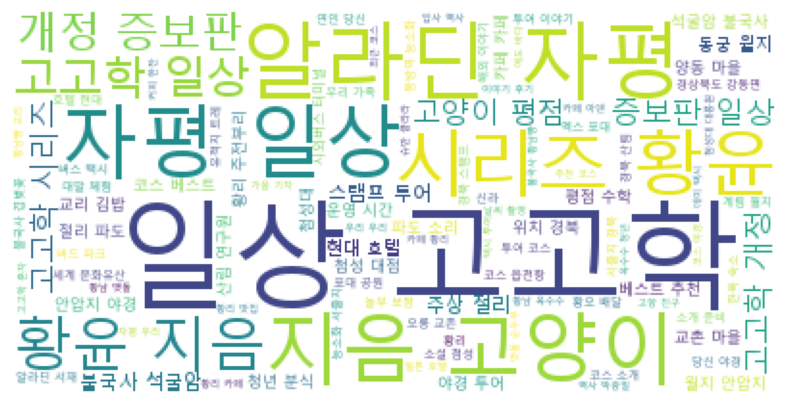

In [84]:
# 경주 명사들만 워드클라우드
import pandas as pd
from wordcloud import WordCloud
from matplotlib import pyplot as plt

df = pd.read_csv('data/quiz_naver_pos_nouns.csv', encoding='cp949')
df_gyeongju = df[df['query'] == '경주 여행'].copy()

df_gyeongju['token'] = df_gyeongju['token']
gyeongju_token_list = ' '.join(df_gyeongju['token']).split()
gyeongju_noun_text = ' '.join(gyeongju_token_list)
plt.rcParams['figure.figsize'] = [10,5]
wordcloud = WordCloud(
                font_path='data/malgun.ttf',
                background_color='white',
                max_words=100, 
                colormap='viridis')
wordcloud.generate(gyeongju_noun_text)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

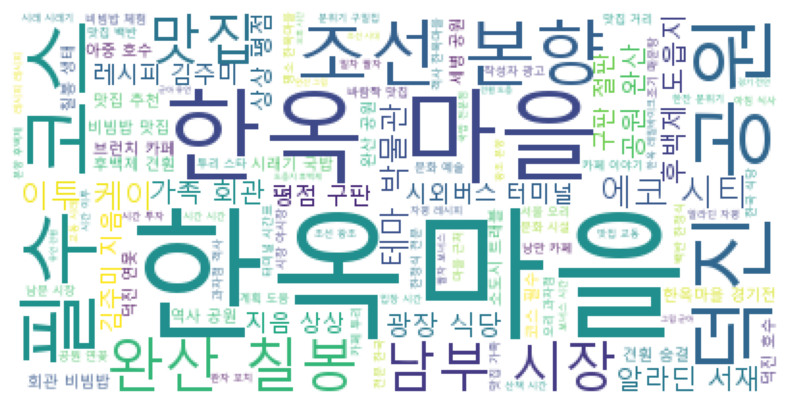

In [85]:
# 전주 명사들만 워드클라우드
df = pd.read_csv('data/quiz_naver_pos_nouns.csv', encoding='cp949')
df_jeonju = df[df['query'] == '전주 여행'].copy()

df_jeonju['token'] = df_jeonju['token']
jeonju_token_list = ' '.join(df_jeonju['token']).split()
jeonju_noun_text = ' '.join(jeonju_token_list)
plt.rcParams['figure.figsize'] = [10,5]
wordcloud = WordCloud(
                font_path='data/malgun.ttf',
                background_color='white',
                max_words=100, 
                colormap='viridis')
wordcloud.generate(jeonju_noun_text)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

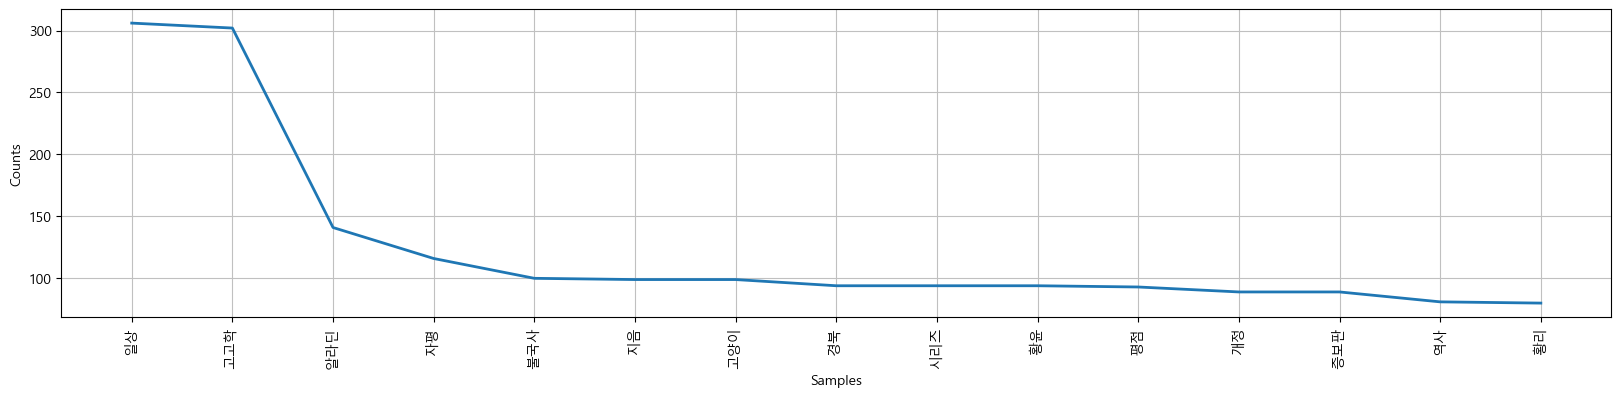

<Axes: xlabel='Samples', ylabel='Counts'>

In [83]:
# 경주 명사들 Text plot
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (20,4)
from nltk import Text
text_plot = Text(gyeongju_token_list)
text_plot.plot(15)

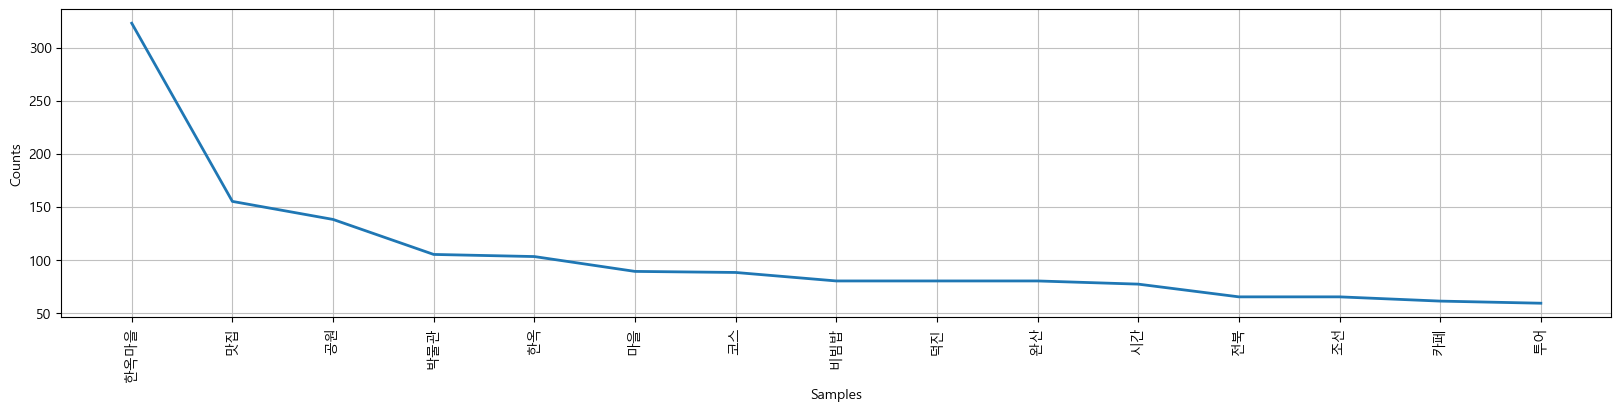

<Axes: xlabel='Samples', ylabel='Counts'>

In [82]:
# 전주 명사들만 Text plot
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (20,4)
from nltk import Text
text_plot = Text(jeonju_token_list)
text_plot.plot(15)

# 6. 워드 임베딩
- Word2Vec

In [86]:
df = pd.read_csv('data/quiz_naver.csv', encoding='cp949')

In [87]:
total_text_list = df['total_text'].values.tolist()
# total_text_list = df['total_text'].to_list() 시리즈를 list로
total_text_list[-2:]

['  전주 여행   한옥마을 내  전주  전통 한지원 전라북도  전주 시 일원에서 생산되는 한지  이곳의 한지제조업은 입지와  전주 천의 깨끗한 수질  원재료     전주 지방 근교에 닥나무가 많이 생산되기 때문에 이를 원재료로 한 한지제조업이 성황을 이루고 있다     ',
 ' 전주 먹방 여행   전주 한옥마을 카페 차미라미 2022 12 20    맛집 맛집들     전주여행   전주 먹방투어 한벽집 새우탕  전주여행   전주 먹방투어 한벽집 새우탕 11월 초에 지인들과  전주 여행 을 다녀왔어요  오로지 먹방투어로 간 1박 2일  전주 여행  쉴새없이    ']

In [88]:
select_pos = ['NNP', 'NNG'] # Komoran, Kkma, MeCab의 일반명사, 고유명사
# select_pos = ['Noun'] # Okt의 일반명사, 고유명사
# select_pos = ['NC', 'NQ']# Hannanum의 보통명사, 고유명사
불용어 = {'여행'}

In [89]:
%%time
from konlpy.tag import Komoran, Kkma, Hannanum, Okt
from mecab import MeCab
analyzer = MeCab()
total_noun_list = []
for total_text in total_text_list:
    noun_list = [word for word, tag in analyzer.pos(total_text) 
                     if tag in select_pos and 
                             len(word)>1 and
                             word not in 불용어] # 명사, 2글자이상, 불용어제외
    total_noun_list.append(noun_list)

CPU times: total: 1.3 s
Wall time: 1.33 s


In [90]:
print(total_noun_list[-2:])

[['전주', '한옥마을', '전주', '전통', '지원', '전라북도', '전주', '일원', '생산', '한지', '한지', '제조업', '입지', '전주', '수질', '원재료', '전주', '지방', '근교', '닥나무', '생산', '원재료', '한지', '제조업', '성황'], ['전주', '먹방', '전주', '한옥', '마을', '카페', '차미', '라미', '맛집', '맛집', '전주', '전주', '먹방', '투어', '새우탕', '전주', '전주', '먹방', '투어', '새우탕', '지인', '전주', '먹방', '투어', '전주']]


In [91]:
from gensim.models import Word2Vec
model = Word2Vec(total_noun_list,
                window=15,
                min_count=20, # 20번 이상 반복되는 단어만 거리계산
                workers=1,
                sg=1)

In [92]:
print(model.wv.index_to_key)
print(len(model.wv))

['전주', '경주', '한옥마을', '일상', '고고학', '알라딘', '맛집', '코스', '공원', '한옥', '마을', '자평', '시간', '투어', '박물관', '지음', '평점', '역사', '카페', '불국사', '고양이', '황윤', '시리즈', '경북', '증보판', '개정', '완산', '덕진', '비빔밥', '황리', '호텔', '야경', '추천', '조선', '전북', '첨성대', '이야기', '체험', '구경', '사진', '시장', '생각', '가을', '한국', '연꽃', '가족', '신라', '방문', '산책', '대릉원', '이번', '버스', '거리', '문화', '필수', '석굴암', '점심', '본향', '서울', '시작', '벚꽃', '터미널', '식당', '숙소', '오늘', '부채', '추억', '후백제', '도착', '보문', '수학', '시외버스', '친구', '아침', '위치', '남부', '현대', '유적지', '계획', '월지', '칠봉', '호수', '하늘', '기대', '저녁', '주차장', '주상', '기차', '아이', '국내', '장소', '경기전', '안압지', '근처', '소리', '전화', '도시', '날씨', '다음', '사람', '갈비', '풍경', '동궁', '도서관', '시티', '에코', '한복', '객사', '광장', '명소', '레시피', '테마', '스탬프', '행복', '서재', '황남', '절리', '대표', '분위기', '생태', '교촌', '후기', '완주', '국밥', '전라북도', '마음', '예전', '전동성당', '커피', '공간', '전통', '오후', '여름', '혼자', '볼거리', '운영', '군산', '음식', '마중', '풍남문', '대한민국', '아중', '견훤', '케이', '이투', '사고', '이색', '먹거리', '만족', '한잔', '순두부', '마지막', '해외', '김밥', '느낌', '검색', '정교', '소개', '입장료', '숨결', '

In [93]:
model.wv.most_similar('전주')

[('경기전', 0.8041083812713623),
 ('한옥마을', 0.7879728674888611),
 ('전국', 0.773904025554657),
 ('이색', 0.745633602142334),
 ('막걸리', 0.7432374954223633),
 ('시민', 0.7361144423484802),
 ('대표', 0.7351630926132202),
 ('도서관', 0.7322400808334351),
 ('전통', 0.7254229784011841),
 ('조선', 0.7252900004386902)]

In [94]:
model.wv.most_similar('경주')

[('신라', 0.8795440793037415),
 ('느낌', 0.8791313767433167),
 ('혼자', 0.8627998232841492),
 ('풍경', 0.8237165808677673),
 ('단풍', 0.817894458770752),
 ('이야기', 0.8074095249176025),
 ('알라딘', 0.8045722246170044),
 ('일상', 0.8012100458145142),
 ('시리즈', 0.7987033128738403),
 ('황윤', 0.7986134886741638)]

In [95]:
# 유사한 단어 출력
print("입력된 단어와 유사한 단어 10개를 출력합니다.")
key = input()
if key in model.wv:
    print("{}와 유사한 단어:".format(key))
    print(model.wv.most_similar(key, topn=10))
else:
    print("{} 단어가 훈련 데이터에 없음".format(key))

입력된 단어와 유사한 단어 10개를 출력합니다.
비빔밥
비빔밥와 유사한 단어:
[('회관', 0.9770257472991943), ('가족', 0.9363639950752258), ('전문점', 0.93271404504776), ('체험', 0.8040167689323425), ('음식', 0.800320565700531), ('국밥', 0.791236400604248), ('검색', 0.7799761295318604), ('맛집', 0.7701323628425598), ('아이', 0.7519062757492065), ('저녁', 0.748276948928833)]
